# Customer Churn Prediction — Feature Engineering & Modelling

## Setup

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv(r'data_ecommerce_customer_churn(Updated).csv')
print('Shape:', df.shape)
df.head()

Shape: (3270, 11)


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,3.0,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


## Feature Engineering

**One-Hot Encoding** — `PreferedOrderCat` and `MaritalStatus` are nominal (no natural order). `drop_first=False` kept since tree models don't suffer from multicollinearity.

In [ ]:
cat_columns = ['PreferedOrderCat', 'MaritalStatus']
df = pd.get_dummies(df, columns=cat_columns, drop_first=False)
print(df.columns.tolist())

['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount', 'Churn', 'PreferedOrderCat_Fashion', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile', 'PreferedOrderCat_Others', 'MaritalStatus_Divorced', 'MaritalStatus_Married', 'MaritalStatus_Single']


**Encoded correlation vs Churn** — `PreferedOrderCat_Mobile` (+0.22) and `MaritalStatus_Single` (+0.17) are the strongest categorical churn predictors. Strong negative values between sibling columns (e.g. Married vs Single = −0.69) are a mathematical artifact of one-hot encoding, not a real insight.

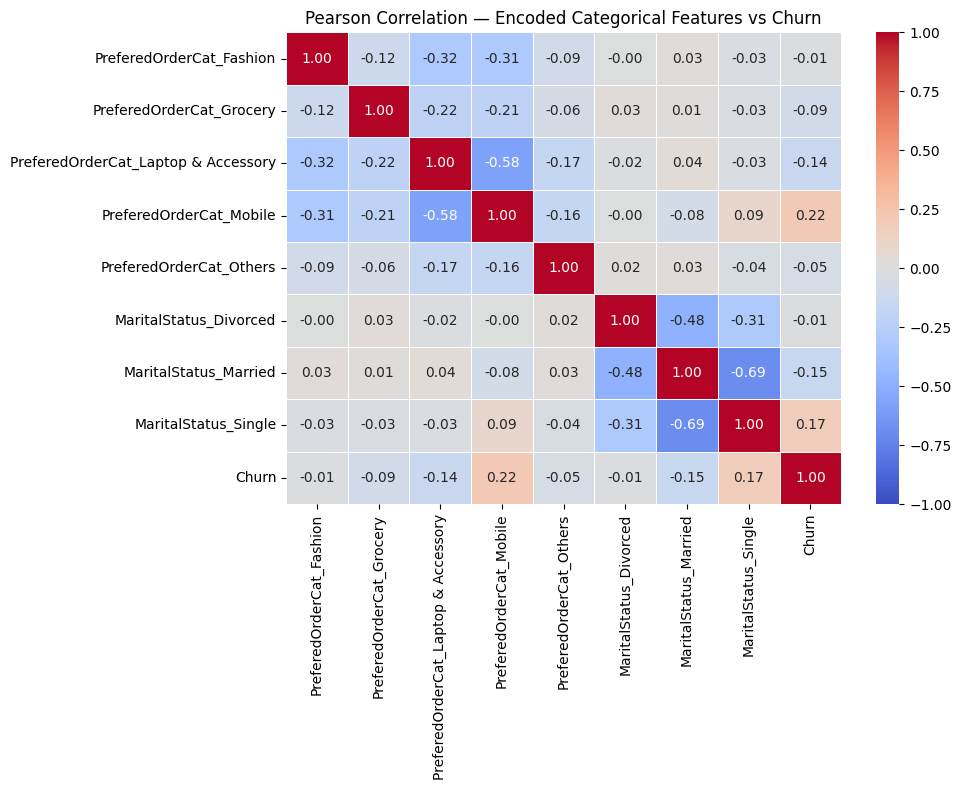

In [ ]:
df_col = [
    'PreferedOrderCat_Fashion', 'PreferedOrderCat_Grocery',
    'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile',
    'PreferedOrderCat_Others', 'MaritalStatus_Divorced',
    'MaritalStatus_Married', 'MaritalStatus_Single', 'Churn'
]
corr_matrix = df[df_col].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Pearson Correlation — Encoded Categorical Features vs Churn')
plt.tight_layout()
plt.show()

**Log-transform** — `Tenure`, `WarehouseToHome`, `DaySinceLastOrder`, `CashbackAmount` are right-skewed. `np.log1p` compresses the scale and handles any zero values safely. Mainly benefits Logistic Regression, KNN, and SVM — tree models are unaffected by scale.

In [ ]:
skew_cols = ['Tenure', 'WarehouseToHome', 'DaySinceLastOrder', 'CashbackAmount']
df[skew_cols] = np.log1p(df[skew_cols])
print('Log-transform applied to:', skew_cols)

Log-transform applied to: ['Tenure', 'WarehouseToHome', 'DaySinceLastOrder', 'CashbackAmount']


## Train / Test Split

`stratify=y` ensures both sets preserve the 83.7%/16.3% churn ratio. Without it, a random split could skew the test set churn rate and make evaluation misleading.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)
print('Train churn rate:', y_train.mean().round(3))
print('Test churn rate:', y_test.mean().round(3))

Train size: (2616, 16)
Test size: (654, 16)
Train churn rate: 0.163
Test churn rate: 0.164


## Scaling & SMOTE

Order: **Scale first, then SMOTE.** SMOTE uses k-nearest neighbours to generate synthetic samples — unscaled features would bias neighbour distances toward large-range columns like CashbackAmount.

Scaler fitted on `X_train` only. SMOTE applied to training set only — test set stays real and imbalanced for honest evaluation.

In [ ]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print('Resampled class distribution:')
print(pd.Series(y_train_resampled).value_counts())

Resampled class distribution:
Churn
0    2189
1    2189
Name: count, dtype: int64


## Model Comparison

Five classifiers trained on SMOTE-resampled data, evaluated on the real imbalanced test set. **Focus on churn class (`1`) F1 and ROC-AUC — not overall accuracy**, which is misleading at 83/17 imbalance.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN':                 KNeighborsClassifier(),
    'SVM':                 SVC(probability=True, random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'XGBoost':             XGBClassifier(random_state=42, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    print(f'--- {name} ---')
    print(classification_report(y_test, y_pred))
    print('ROC-AUC:', roc_auc_score(y_test, y_proba))
    print(confusion_matrix(y_test, y_pred))
    print()

    results[name] = {
        'roc_auc': roc_auc_score(y_test, y_proba),
        'y_pred': y_pred, 'y_proba': y_proba
    }

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.98      0.81      0.89       547
           1       0.48      0.92      0.63       107

    accuracy                           0.83       654
   macro avg       0.73      0.86      0.76       654
weighted avg       0.90      0.83      0.84       654

ROC-AUC: 0.9220728186027439
[[442 105]
 [  9  98]]

--- KNN ---
              precision    recall  f1-score   support

           0       0.98      0.84      0.90       547
           1       0.52      0.90      0.66       107

    accuracy                           0.85       654
   macro avg       0.75      0.87      0.78       654
weighted avg       0.90      0.85      0.86       654

ROC-AUC: 0.9096089118214902
[[457  90]
 [ 11  96]]

--- SVM ---
              precision    recall  f1-score   support

           0       0.97      0.86      0.91       547
           1       0.54      0.84      0.65       107

    accuracy              

**Result** — LR, KNN, SVM: high recall but low precision (too many false alarms). RF and XGBoost: better precision/recall balance — tree ensembles capture non-linear feature interactions that linear models miss. **XGBoost selected for tuning** (best F1 = 0.78, ROC-AUC = 0.957).

## Hyperparameter Tuning — XGBoost

`scoring='f1'` optimises for minority-class F1. `StratifiedKFold` preserves churn ratio across all 5 folds.

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.01, 0.1, 0.2],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid,
                           scoring='f1', cv=cv, n_jobs=-1, verbose=1)
grid_search.fit(X_train_resampled, y_train_resampled)

print('Best params:', grid_search.best_params_)
print('Best CV F1:', grid_search.best_score_)
best_xgb = grid_search.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
Best CV F1: 0.955324228445536


In [ ]:
y_pred_tuned  = best_xgb.predict(X_test_scaled)
y_proba_tuned = best_xgb.predict_proba(X_test_scaled)[:, 1]

print('--- Tuned XGBoost ---')
print(classification_report(y_test, y_pred_tuned))
print('ROC-AUC:', roc_auc_score(y_test, y_proba_tuned))

--- Tuned XGBoost ---
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       547
           1       0.78      0.81      0.79       107

    accuracy                           0.93       654
   macro avg       0.87      0.88      0.88       654
weighted avg       0.93      0.93      0.93       654

ROC-AUC: 0.9608911821490201


**Tuning result** — CV F1 was 0.954 but test F1 dropped to 0.77 (below untuned baseline of 0.78). The tuned model (`max_depth=7`) overfit slightly to SMOTE's synthetic samples. **Untuned XGBoost retained as final model** — a valid finding that CV score alone is not sufficient proof of generalisation.

## SHAP Explainability

Global feature importance across the test set. Each dot = one customer. Red = high feature value, Blue = low. Right = pushes toward churn, Left = away from churn.

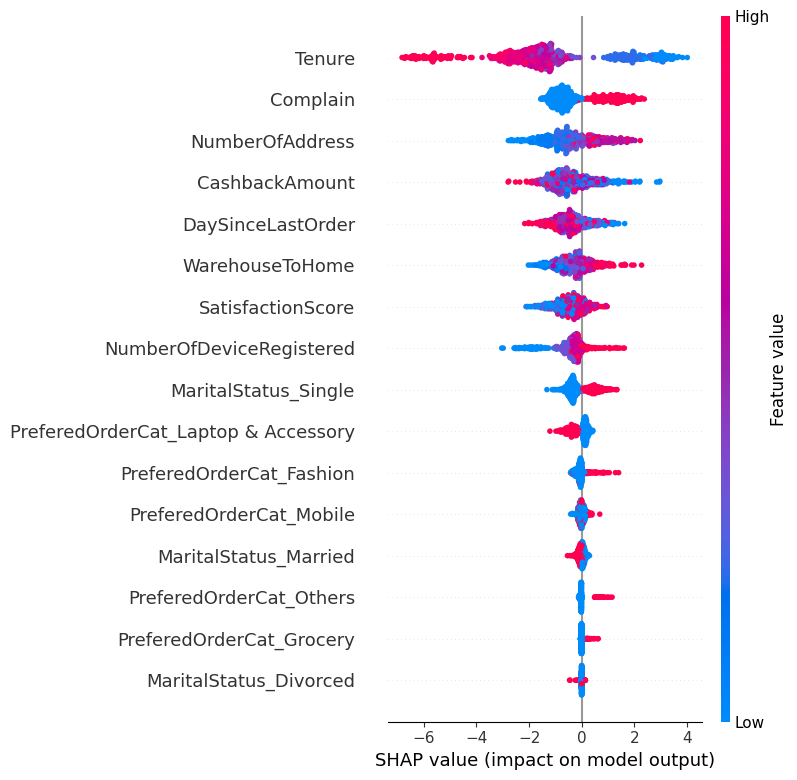

In [ ]:
import shap

explainer   = shap.TreeExplainer(models['XGBoost'])
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

**SHAP findings:**
- `Tenure` (#1): low tenure → high churn risk. Matches −0.34 correlation.
- `Complain` (#2): complainers push strongly toward churn.
- `CashbackAmount` (#4): high cashback = retained customers.
- `PreferedOrderCat_Mobile` ranks 13th despite +0.22 correlation — its effect is already captured by Tenure and Complain. Shows the difference between univariate correlation and model-level feature importance.

## Save Model & Scaler

Both files needed for Streamlit deployment — scaler to preprocess new input consistently, model to predict.

In [ ]:
import joblib

model = joblib.load('xgboost_churn_model.pkl')
scaler = joblib.load('scaler.pkl')

print('Saved: xgboost_churn_model.pkl')
print('Saved: scaler.pkl')

Saved: xgboost_churn_model.pkl
Saved: scaler.pkl


In [ ]:
import zipfile
from google.colab import files

zip_filename = "churn_model_files.zip"

with zipfile.ZipFile(zip_filename, "w") as zipf:
    zipf.write("xgboost_churn_model.pkl")
    zipf.write("scaler.pkl")

files.download(zip_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>